In [1]:
import pandas as pd

cols = [
"target",
"target_accession",
"tlen",
"query",
"query_accession",
"qlen",
"Evalue",
"score",
"bias",
"dom_num",
"dom_of",
"cEvalue",
"iEvalue",
"dom_score",
"dom_bias",
"hmm_from",
"hmm_to",
"ali_from",
"ali_to",
"env_from",
"env_to",
"acc",
"description"
]

dbcan = pd.read_csv(
    "../results/dbcan_hits.txt",
    comment="#",
    sep=r"\s+",
    names=cols,
    engine="python"
)

dbcan.head()

,target,target_accession,tlen,query,query_accession,qlen,Evalue,score,bias,dom_num,...,dom_score,dom_bias,hmm_from,hmm_to,ali_from,ali_to,env_from,env_to,acc,description
0,AA9.hmm,-,220,sp|G0R6T8|LP9A_HYPJQ,-,344,1.400000e-68,226.6,1.2,1,...,226.3,0.1,2,219,10,233,9,234,0.89,-
1,AA9.hmm,-,220,sp|G0R6T8|LP9A_HYPJQ,-,344,1.400000e-68,226.6,1.2,2,...,-1.6,0.1,44,76,272,305,244,323,0.56,-
2,CBM1.hmm,-,29,sp|G0R6T8|LP9A_HYPJQ,-,344,1.000000e-14,50.0,5.7,1,...,48.7,5.7,2,29,312,339,311,339,0.98,-
3,CBM39.hmm,-,94,sp|G0R6T8|LP9A_HYPJQ,-,344,8.300000e-03,11.9,0.0,1,...,-1.0,0.0,62,75,86,99,78,103,0.78,-
4,CBM39.hmm,-,94,sp|G0R6T8|LP9A_HYPJQ,-,344,8.300000e-03,11.9,0.0,2,...,9.9,0.0,40,86,144,189,126,196,0.78,-


In [2]:
# functional descriptions
class_dict = {
"GH": "Glycoside Hydrolase – hydrolytic cleavage of glycosidic bonds",
"GT": "GlycosylTransferase – formation of glycosidic bonds",
"PL": "Polysaccharide Lyase – cleavage of polysaccharides via elimination",
"CE": "Carbohydrate Esterase – removes acetyl/methyl groups from sugars",
"AA": "Auxiliary Activity enzyme – oxidative enzymes assisting polysaccharide degradation",
"CBM": "Carbohydrate Binding Module – non-catalytic carbohydrate-binding domain"
}

cazy_dict = {

"AA1":"laccase (multicopper oxidase)",
"AA1_1":"laccase-like oxidase",
"AA1_2":"laccase-like oxidase",
"AA1_3":"multicopper oxidase",

"AA2":"peroxidase",
"AA5":"copper radical oxidase",
"AA7":"oligosaccharide oxidase",
"AA9":"lytic polysaccharide monooxygenase",

"GH2":"β-galactosidase family",
"GH2_2":"β-galactosidase",
"GH2_14":"β-galactosidase",

"GH3":"β-glucosidase",

"GH16":"β-glucanase",
"GH16_21":"β-glucanase",

"GH18":"chitinase",

"GH27":"α-galactosidase",
"GH31":"α-glucosidase",
"GH31_11":"α-glucosidase",

"GH36":"α-galactosidase",

"GH55":"β-1,3-glucanase",
"GH55_2":"β-1,3-glucanase",
"GH55_3":"β-1,3-glucanase",

"GH74":"xyloglucanase",

"GH30_6":"glucuronoxylanase",
"GH30_12":"xylanase",

"GH92":"mannosidase",

"GH6":"cellobiohydrolase",
"GH7":"cellobiohydrolase",

"CBM1":"cellulose-binding module"
}

In [3]:
## Filter good hits
hits = dbcan[dbcan["Evalue"] < 1e-15]

# Extract CAZyme family
hits["family"] = hits["target"].str.replace(".hmm","", regex=False)

#Count enzyme families
family_counts = hits["family"].value_counts()

family_counts = family_counts.reset_index()
family_counts.columns = ["family","count"]

family_counts["description"] = family_counts["family"].map(cazy_dict)

family_counts

,family,count,description
0,AA5,17,copper radical oxidase
1,GH18,16,chitinase
2,GH74,13,xyloglucanase
3,AA7,12,oligosaccharide oxidase
4,AA1_2,12,laccase-like oxidase
...,...,...,...
250,PL8,1,NaN
251,GH16_8,1,NaN
252,GH16_23,1,NaN
253,GH16_22,1,NaN


In [4]:
hits['query']

0         sp|G0R6T8|LP9A_HYPJQ
1         sp|G0R6T8|LP9A_HYPJQ
5         sp|G0RUP7|XYN2_HYPJQ
8          sp|G0RV93|GCE_HYPJQ
14        sp|Q7Z9M7|LP9B_HYPJQ
                 ...          
1410    tr|G0RXI7|G0RXI7_HYPJQ
1411    tr|G0RXI7|G0RXI7_HYPJQ
1412    tr|G0RXI7|G0RXI7_HYPJQ
1413    tr|G0RXI7|G0RXI7_HYPJQ
1414    tr|G0RXL3|G0RXL3_HYPJQ
Name: query, Length: 688, dtype: str

In [5]:
hits

,target,target_accession,tlen,query,query_accession,qlen,Evalue,score,bias,dom_num,...,dom_bias,hmm_from,hmm_to,ali_from,ali_to,env_from,env_to,acc,description,family
0,AA9.hmm,-,220,sp|G0R6T8|LP9A_HYPJQ,-,344,1.400000e-68,226.6,1.2,1,...,0.1,2,219,10,233,9,234,0.89,-,AA9
1,AA9.hmm,-,220,sp|G0R6T8|LP9A_HYPJQ,-,344,1.400000e-68,226.6,1.2,2,...,0.1,44,76,272,305,244,323,0.56,-,AA9
5,GH11.hmm,-,177,sp|G0RUP7|XYN2_HYPJQ,-,223,1.600000e-76,251.6,16.7,1,...,16.7,1,177,44,221,44,221,0.99,-,GH11
8,CE15.hmm,-,269,sp|G0RV93|GCE_HYPJQ,-,460,1.100000e-92,306.1,0.0,1,...,0.0,1,268,110,431,110,432,0.96,-,CE15
14,AA9.hmm,-,220,sp|Q7Z9M7|LP9B_HYPJQ,-,249,1.200000e-61,203.9,1.9,1,...,1.9,2,219,8,234,7,235,0.91,-,AA9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1410,AA5_1.hmm,-,563,tr|G0RXI7|G0RXI7_HYPJQ,-,1119,1.600000e-139,461.4,2.1,4,...,0.2,59,86,428,462,375,472,0.61,-,AA5_1
1411,AA5_1.hmm,-,563,tr|G0RXI7|G0RXI7_HYPJQ,-,1119,1.600000e-139,461.4,2.1,5,...,2.1,5,554,610,1113,606,1118,0.95,-,AA5_1
1412,AA5_2.hmm,-,607,tr|G0RXI7|G0RXI7_HYPJQ,-,1119,1.000000e-28,96.1,3.7,1,...,1.6,177,262,650,754,594,761,0.64,-,AA5_2
1413,AA5_2.hmm,-,607,tr|G0RXI7|G0RXI7_HYPJQ,-,1119,1.000000e-28,96.1,3.7,2,...,0.0,396,606,887,1098,859,1099,0.86,-,AA5_2


In [6]:
family_counts

,family,count,description
0,AA5,17,copper radical oxidase
1,GH18,16,chitinase
2,GH74,13,xyloglucanase
3,AA7,12,oligosaccharide oxidase
4,AA1_2,12,laccase-like oxidase
...,...,...,...
250,PL8,1,NaN
251,GH16_8,1,NaN
252,GH16_23,1,NaN
253,GH16_22,1,NaN


In [7]:
family_counts.columns
family_counts[family_counts['family']=="AA9"]


,family,count,description
57,AA9,3,lytic polysaccharide monooxygenase


In [8]:
# Count enzyme classes
hits["class"] = hits["family"].str.extract("(GH|AA|CBM|CE|PL|GT)")
hits["class_description"] = hits["class"].map(class_dict)
class_counts = hits["class"].value_counts()

class_counts

class
GH     544
AA      95
PL      19
CBM     16
CE       9
GT       5
Name: count, dtype: int64

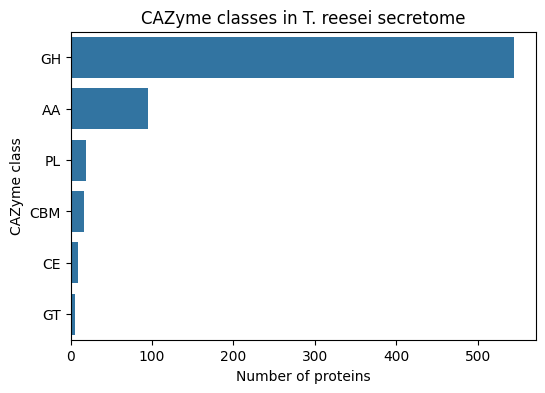

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.barplot(
    x=class_counts.values,
    y=class_counts.index
)

plt.xlabel("Number of proteins")
plt.ylabel("CAZyme class")
plt.title("CAZyme classes in T. reesei secretome")

plt.show()

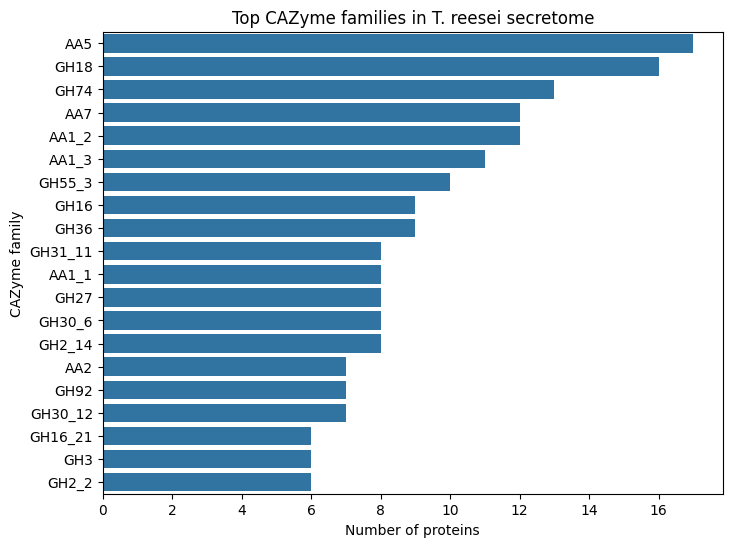

In [10]:
top20 = family_counts.head(20)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top20["count"],
    y=top20["family"]
)

plt.xlabel("Number of proteins")
plt.ylabel("CAZyme family")
plt.title("Top CAZyme families in T. reesei secretome")
plt.savefig("N:\Jupiter_Projects\enzyme-genome-mining-course/results/figures/cazyme_families.png")
plt.show()

In [11]:
hits["query"].nunique()

178

In [12]:
proteins = hits.drop_duplicates("query")
len(proteins)

178

In [13]:
#Domain architecture analysis
hits["query"].value_counts().head(20)

query
tr|G0RFR8|G0RFR8_HYPJQ    69
tr|G0RWC5|G0RWC5_HYPJQ    39
tr|G0RT85|G0RT85_HYPJQ    38
tr|G0RGK8|G0RGK8_HYPJQ    36
tr|G0RG98|G0RG98_HYPJQ    36
tr|G0RH14|G0RH14_HYPJQ    22
tr|G0RVK4|G0RVK4_HYPJQ    18
tr|G0RV92|G0RV92_HYPJQ    15
tr|G0RVQ8|G0RVQ8_HYPJQ    14
tr|G0RNW1|G0RNW1_HYPJQ    13
tr|G0RXI7|G0RXI7_HYPJQ    11
tr|G0RE86|G0RE86_HYPJQ    10
tr|G0RV96|G0RV96_HYPJQ    10
tr|G0RC85|G0RC85_HYPJQ     9
tr|G0R8D1|G0R8D1_HYPJQ     8
tr|G0RRQ7|G0RRQ7_HYPJQ     8
tr|G0R9J5|G0R9J5_HYPJQ     8
tr|G0RCD8|G0RCD8_HYPJQ     7
tr|G0RFB0|G0RFB0_HYPJQ     7
tr|G0RG36|G0RG36_HYPJQ     7
Name: count, dtype: int64

In [14]:
# Domain architecture analysis. CBM modules improve substrate binding.
cbm_hits = hits[hits["class"] == "CBM"]

len(cbm_hits["query"].unique())

11

In [15]:
#Identify cellulase system explicitly
cellulases = hits[hits["family"].str.contains("GH5|GH6|GH7|AA9")]
cellulases["query"].nunique()

43

In [16]:
hits[hits["family"] == "CBM1"]

,target,target_accession,tlen,query,query_accession,qlen,Evalue,score,bias,dom_num,...,hmm_to,ali_from,ali_to,env_from,env_to,acc,description,family,class,class_description
236,CBM1.hmm,-,29,tr|G0RB58|G0RB58_HYPJQ,-,471,3.400000e-16,54.8,15.9,1,...,29,31,58,30,58,0.99,-,CBM1,CBM,Carbohydrate Binding Module – non-catalytic ca...
852,CBM1.hmm,-,29,tr|G0R6T7|G0R6T7_HYPJQ,-,316,1.900000e-16,55.6,8.1,1,...,29,284,312,284,312,0.99,-,CBM1,CBM,Carbohydrate Binding Module – non-catalytic ca...


In [17]:
hits[hits["query"] == "tr|G0RFR8|G0RFR8_HYPJQ"][["family","ali_from","ali_to"]]

,family,ali_from,ali_to
353,GH13_1,58,346
354,GH13_45,58,344
355,GH13,59,346
356,GH13_2,58,342
357,GH13_41,58,342
...,...,...,...
417,GH13_9,69,215
418,GH13_26,68,167
419,GH13_26,177,212
420,GH13_24,103,139


<Axes: xlabel='is_cbm', ylabel='Count'>

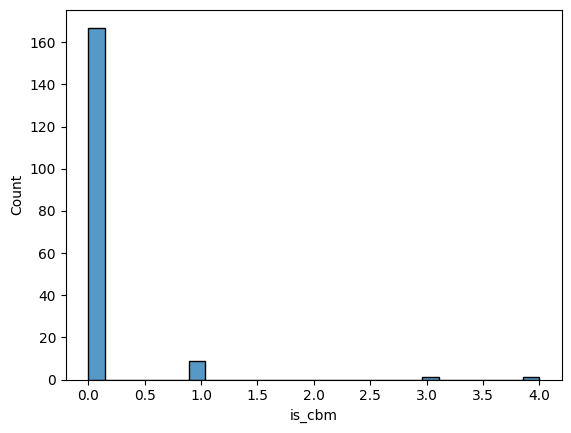

In [18]:
hits["is_cbm"] = hits["class"] == "CBM"

cbm_per_protein = hits.groupby("query")["is_cbm"].sum()
sns.histplot(cbm_per_protein)

In [19]:
# Filter overlapping domain hits:  Remove domains overlapping >20%

df3 = pd.read_csv("../results/proteome_signalp_annotated.csv")
dbcan = pd.read_csv(
    "../results/dbcan_hits.txt",
    comment="#",
    sep=r"\s+",
    names=cols,
    engine="python"
)
dbcan["family"] = dbcan["target"].str.replace(".hmm","", regex=False)
dbcan["class"] = dbcan["family"].str.extract(r'^(GH|GT|PL|CE|AA|CBM)')


In [20]:
#process proteins one by one
#sort domains by start
#keep best scoring non-overlapping hits
def filter_overlapping_domains(df, overlap_threshold=0.2): # Remove domains overlapping >20%

    filtered_rows = []

    for protein, group in df.groupby("query"):

        # sort domains by score (best first)
        group = group.sort_values("score", ascending=False)

        kept = []

        for _, row in group.iterrows():

            start = row["ali_from"]
            end = row["ali_to"]

            overlap = False

            for kept_row in kept:

                s2 = kept_row["ali_from"]
                e2 = kept_row["ali_to"]

                overlap_len = max(0, min(end, e2) - max(start, s2))
                length = end - start

                if overlap_len / length > overlap_threshold:
                    overlap = True
                    break

            if not overlap:
                kept.append(row)

        filtered_rows.extend(kept)

    return pd.DataFrame(filtered_rows)

In [21]:
hits_filtered = filter_overlapping_domains(hits)
len(hits), len(hits_filtered)

(688, 248)

In [28]:
domain_counts = hits_filtered["query"].value_counts().reset_index()
domain_counts.columns = ["protein_id","domain_count"]

In [29]:
domain_counts = domain_counts.merge(
    df3[["protein_id","length"]],
    on="protein_id"
)

In [30]:
domain_counts

,protein_id,domain_count,length
0,sp|Q7Z9M8|XG74_HYPJQ,6,838
1,tr|G0RCD8|G0RCD8_HYPJQ,6,1508
2,tr|G0RCZ5|G0RCZ5_HYPJQ,5,947
3,tr|G0R900|G0R900_HYPJQ,4,927
4,tr|G0RFC1|G0RFC1_HYPJQ,4,473
...,...,...,...
173,tr|G0RWL7|G0RWL7_HYPJQ,1,501
174,tr|G0RWT4|G0RWT4_HYPJQ,1,396
175,tr|G0RX78|G0RX78_HYPJQ,1,763
176,tr|G0RXC7|G0RXC7_HYPJQ,1,438


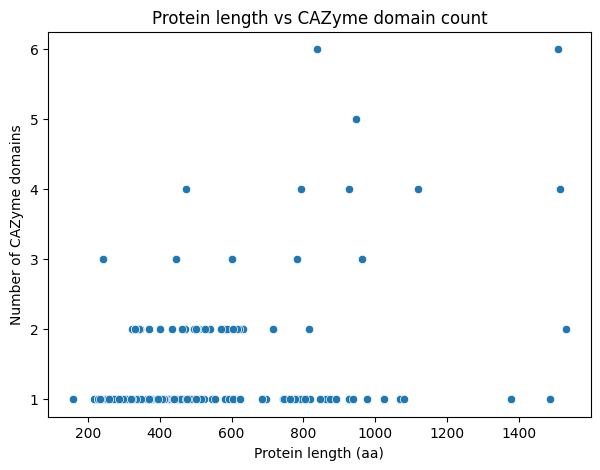

In [31]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=domain_counts,
    x="length",
    y="domain_count"
)

plt.xlabel("Protein length (aa)")
plt.ylabel("Number of CAZyme domains")
plt.title("Protein length vs CAZyme domain count")

plt.show()

In [32]:
domain_counts["domain_count"].describe()

count    178.000000
mean       1.393258
std        0.871624
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        6.000000
Name: domain_count, dtype: float64

In [33]:
domain_distribution = domain_counts["domain_count"].value_counts().sort_index()

domain_distribution

domain_count
1    134
2     31
3      5
4      5
5      1
6      2
Name: count, dtype: int64

In [34]:
domain_distribution = domain_distribution.reset_index()
domain_distribution.columns = ["domain_count", "protein_count"]

domain_distribution

,domain_count,protein_count
0,1,134
1,2,31
2,3,5
3,4,5
4,5,1
5,6,2


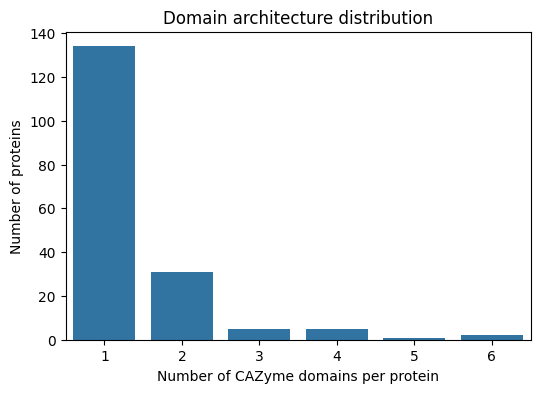

In [35]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=domain_distribution,
    x="domain_count",
    y="protein_count"
)

plt.xlabel("Number of CAZyme domains per protein")
plt.ylabel("Number of proteins")
plt.title("Domain architecture distribution")

plt.show()

In [63]:
#Domain architecture table
hits_filtered["domain"] = hits_filtered["family"]
architecture = (
    hits_filtered
    .sort_values(["query","ali_from"])
    .groupby("query")["domain"]
    .apply(list)
    .reset_index()
)
architecture["domain_architecture"] = architecture["domain"].apply(
    lambda x: " + ".join(x)
)


In [64]:
architecture = architecture.merge(
    df3[["protein_id","length"]],
    left_on="query",
    right_on="protein_id"
)

In [65]:
architecture["domain_count"] = architecture["domain"].apply(len)
architecture = architecture[
    ["protein_id", "length", "domain_count", "domain_architecture"]
]

architecture = architecture.sort_values("domain_count", ascending=False)

architecture.head(20)

,protein_id,length,domain_count,domain_architecture
10,sp|Q7Z9M8|XG74_HYPJQ,838,6,GH74 + GH74 + GH74 + GH74 + GH74 + GH74
48,tr|G0RCD8|G0RCD8_HYPJQ,1508,6,GH74 + GH74 + GH74 + GH74 + GH74 + GH74
52,tr|G0RCZ5|G0RCZ5_HYPJQ,947,5,AA5 + AA5 + AA5 + AA5 + AA5
21,tr|G0R900|G0R900_HYPJQ,927,4,AA2 + AA5 + AA5 + AA5
66,tr|G0RFC1|G0RFC1_HYPJQ,473,4,CBM50 + CBM50 + CBM50 + CBM50
112,tr|G0RPB5|G0RPB5_HYPJQ,1515,4,AA5 + AA5 + AA5 + AA5
176,tr|G0RXI7|G0RXI7_HYPJQ,1119,4,AA5 + AA5 + AA5 + AA5
172,tr|G0RX73|G0RX73_HYPJQ,792,4,AA2 + AA2 + AA2 + AA2
144,tr|G0RTX6|G0RTX6_HYPJQ,782,3,PL8_3 + PL8_4 + PL8_4
46,tr|G0RC44|G0RC44_HYPJQ,444,3,GH36 + GH27 + GH27


In [66]:
architecture.to_csv(
    "../results/cazyme_domain_architecture.csv",
    index=False
)

In [39]:
architecture["domain_architecture"].value_counts().head(20)

domain_architecture
GH18                                       8
GH92                                       7
GH3                                        6
AA7 + AA7                                  5
GH18 + GH18                                4
GH55_2                                     4
GH76                                       4
GH28                                       4
GH27                                       3
AA1                                        3
AA11                                       3
CE5                                        3
GH128                                      3
GH72                                       3
GH20                                       3
GH75                                       3
GH74 + GH74 + GH74 + GH74 + GH74 + GH74    2
AA5 + AA5 + AA5 + AA5                      2
GH54 + CBM42                               2
GH71 + CBM24                               2
Name: count, dtype: int64

In [58]:
hits[hits["query"] == "tr|G0RX73|G0RX73_HYPJQ"][["family","ali_from","ali_to"]]

,family,ali_from,ali_to
15,AA2,128,228
16,AA2,286,334
17,AA2,356,463
18,AA2,518,781


In [44]:
# Adding coverage filter
def filter_domains(df, overlap_threshold=0.2, coverage_threshold=0.35):

    # calculate HMM coverage
    df = df.copy()
    df["coverage"] = (df["hmm_to"] - df["hmm_from"]) / df["tlen"]

    # remove low coverage hits
    df = df[df["coverage"] >= coverage_threshold]

    filtered_rows = []

    for protein, group in df.groupby("query"):

        # best scoring hits first
        group = group.sort_values("score", ascending=False)

        kept = []

        for _, row in group.iterrows():

            start = row["ali_from"]
            end = row["ali_to"]

            overlap = False

            for kept_row in kept:

                s2 = kept_row["ali_from"]
                e2 = kept_row["ali_to"]

                overlap_len = max(0, min(end, e2) - max(start, s2))
                length = end - start

                if overlap_len / length > overlap_threshold:
                    overlap = True
                    break

            if not overlap:
                kept.append(row)

        filtered_rows.extend(kept)

    return pd.DataFrame(filtered_rows)

In [45]:
hits_filtered2 = filter_domains(hits)
len(hits), len(hits_filtered2)

(688, 191)

In [49]:
hits_filtered2.columns

Index(['target', 'target_accession', 'tlen', 'query', 'query_accession',
       'qlen', 'Evalue', 'score', 'bias', 'dom_num', 'dom_of', 'cEvalue',
       'iEvalue', 'dom_score', 'dom_bias', 'hmm_from', 'hmm_to', 'ali_from',
       'ali_to', 'env_from', 'env_to', 'acc', 'description', 'family', 'class',
       'class_description', 'is_cbm', 'coverage'],
      dtype='str')

In [54]:
hits_filtered2["domain"] = hits_filtered2["family"]
architecture2 = (
    hits_filtered2
    .sort_values(["query", "ali_from"])
    .groupby("query")["domain"]
    .apply(list)
    .reset_index()
)
architecture2["domain_architecture"] = architecture2["domain"].apply(
    lambda x: " + ".join(x)
)
architecture2 = architecture2.merge(
    df3[["protein_id", "length"]],
    left_on="query",
    right_on="protein_id"
)
architecture2["domain_count"] = architecture2["domain"].apply(len)
architecture2 = architecture2[
    ["protein_id", "length", "domain_count", "domain_architecture"]
]
architecture2 = architecture2.sort_values(
    ["domain_count", "length"],
    ascending=[False, False]
)
architecture2

,protein_id,length,domain_count,domain_architecture
64,tr|G0RFC1|G0RFC1_HYPJQ,473,4,CBM50 + CBM50 + CBM50 + CBM50
10,sp|Q7Z9M8|XG74_HYPJQ,838,3,GH74 + GH74 + GH74
168,tr|G0RX73|G0RX73_HYPJQ,792,3,AA2 + AA2 + AA2
172,tr|G0RXI7|G0RXI7_HYPJQ,1119,2,AA5_1 + AA5
18,tr|G0R866|G0R866_HYPJQ,632,2,GH15 + CBM20
...,...,...,...,...
2,sp|G0R947|XYN1_HYPJQ,229,1,GH11
133,tr|G0RT43|G0RT43_HYPJQ,229,1,GH75
38,tr|G0RAJ4|G0RAJ4_HYPJQ,228,1,GH25
7,sp|G0RUP7|XYN2_HYPJQ,223,1,GH11


In [52]:
architecture2.to_csv(
    "../results/cazyme_architecture_filtered.csv",
    index=False
)

In [69]:
cazyme_fraction = architecture.shape[0] / 679
cazyme_fraction

0.2621502209131075

In [70]:
#Domain merging function
def merge_same_family_domains(df, max_gap=80):

    merged_rows = []

    for protein, group in df.groupby("query"):

        group = group.sort_values("ali_from")

        current = None

        for _, row in group.iterrows():

            if current is None:
                current = row.copy()
                continue

            same_family = row["family"] == current["family"]
            gap = row["ali_from"] - current["ali_to"]

            if same_family and gap <= max_gap:

                current["ali_to"] = max(current["ali_to"], row["ali_to"])

            else:
                merged_rows.append(current)
                current = row.copy()

        if current is not None:
            merged_rows.append(current)

    return pd.DataFrame(merged_rows)

In [71]:
hits_merged = merge_same_family_domains(hits_filtered2)

In [72]:
len(hits), len(hits_filtered), len(hits_filtered2), len(hits_merged)

(688, 248, 191, 187)

In [73]:
architecture3 = (
    hits_merged
    .sort_values(["query", "ali_from"])
    .groupby("query")["domain"]
    .apply(list)
    .reset_index()
)
architecture3["domain_architecture"] = architecture3["domain"].apply(
    lambda x: " + ".join(x)
)
architecture3 = architecture3.merge(
    df3[["protein_id", "length"]],
    left_on="query",
    right_on="protein_id"
)
architecture3["domain_count"] = architecture3["domain"].apply(len)
architecture3 = architecture3[
    ["protein_id", "length", "domain_count", "domain_architecture"]
]
architecture3 = architecture3.sort_values(
    ["domain_count", "length"],
    ascending=[False, False]
)
architecture3

,protein_id,length,domain_count,domain_architecture
172,tr|G0RXI7|G0RXI7_HYPJQ,1119,2,AA5_1 + AA5
10,sp|Q7Z9M8|XG74_HYPJQ,838,2,GH74 + GH74
168,tr|G0RX73|G0RX73_HYPJQ,792,2,AA2 + AA2
18,tr|G0R866|G0R866_HYPJQ,632,2,GH15 + CBM20
58,tr|G0REY1|G0REY1_HYPJQ,622,2,GH71 + CBM24
...,...,...,...,...
2,sp|G0R947|XYN1_HYPJQ,229,1,GH11
133,tr|G0RT43|G0RT43_HYPJQ,229,1,GH75
38,tr|G0RAJ4|G0RAJ4_HYPJQ,228,1,GH25
7,sp|G0RUP7|XYN2_HYPJQ,223,1,GH11


In [74]:
architecture3.to_csv(
    "../results/cazyme_architecture_filtered_merged.csv",
    index=False
)

In [77]:
cazyme_fraction = architecture3.shape[0] / 679
cazyme_fraction

0.25625920471281294

In [76]:
architecture3["domain_architecture"].value_counts().head(20)

domain_architecture
GH18            12
GH92             7
AA7              7
GH3              6
GH27             6
GH55_2           4
GH76             4
GH28             4
AA2              3
GH20             3
AA1              3
GH72             3
AA11             3
GH16_18          3
GH128            3
CE5              3
GH75             3
GH71 + CBM24     2
GH72 + CBM43     2
GH54 + CBM42     2
Name: count, dtype: int64

In [78]:
domain_counts = hits_merged["query"].value_counts().reset_index()
domain_counts.columns = ["protein_id","domain_count"]
domain_counts = domain_counts.merge(
    df3[["protein_id","length"]],
    on="protein_id"
)

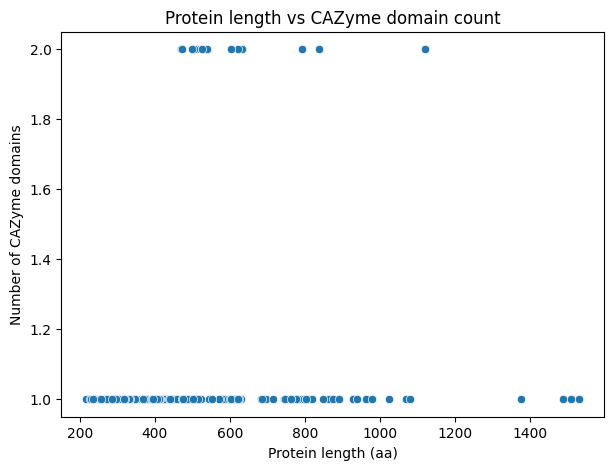

In [79]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=domain_counts,
    x="length",
    y="domain_count"
)

plt.xlabel("Protein length (aa)")
plt.ylabel("Number of CAZyme domains")
plt.title("Protein length vs CAZyme domain count")

plt.show()

In [80]:
domain_counts["domain_count"].describe()

count    174.000000
mean       1.074713
std        0.263686
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: domain_count, dtype: float64

In [83]:
domain_distribution = domain_counts["domain_count"].value_counts().sort_index()

domain_distribution = domain_distribution.reset_index()
domain_distribution.columns = ["domain_count", "protein_count"]

domain_distribution

,domain_count,protein_count
0,1,161
1,2,13


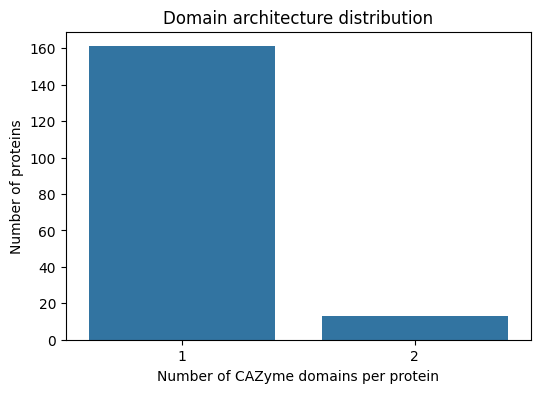

In [84]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=domain_distribution,
    x="domain_count",
    y="protein_count"
)

plt.xlabel("Number of CAZyme domains per protein")
plt.ylabel("Number of proteins")
plt.title("Domain architecture distribution")

plt.show()

In [85]:
# Count enzyme classes
hits["class"] = hits_merged["family"].str.extract("(GH|AA|CBM|CE|PL|GT)")
hits["class_description"] = hits_merged["class"].map(class_dict)
class_counts = hits_merged["class"].value_counts()

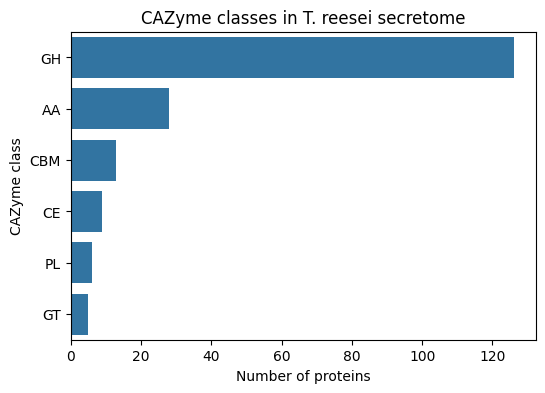

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.barplot(
    x=class_counts.values,
    y=class_counts.index
)

plt.xlabel("Number of proteins")
plt.ylabel("CAZyme class")
plt.title("CAZyme classes in T. reesei secretome")
plt.savefig("N:\Jupiter_Projects\enzyme-genome-mining-course/results/figures/cazyme_classes.png")
plt.show()

In [87]:
#Count enzyme families
family_counts = hits_merged["family"].value_counts()

family_counts = family_counts.reset_index()
family_counts.columns = ["family","count"]

family_counts["description"] = family_counts["family"].map(cazy_dict)

In [90]:
family_counts

,family,count,description
0,GH18,12,chitinase
1,AA7,7,oligosaccharide oxidase
2,GH92,7,mannosidase
3,GH27,6,α-galactosidase
4,GH3,6,β-glucosidase
...,...,...,...
87,GT15,1,NaN
88,GH16_23,1,NaN
89,AA5_1,1,NaN
90,AA5,1,copper radical oxidase


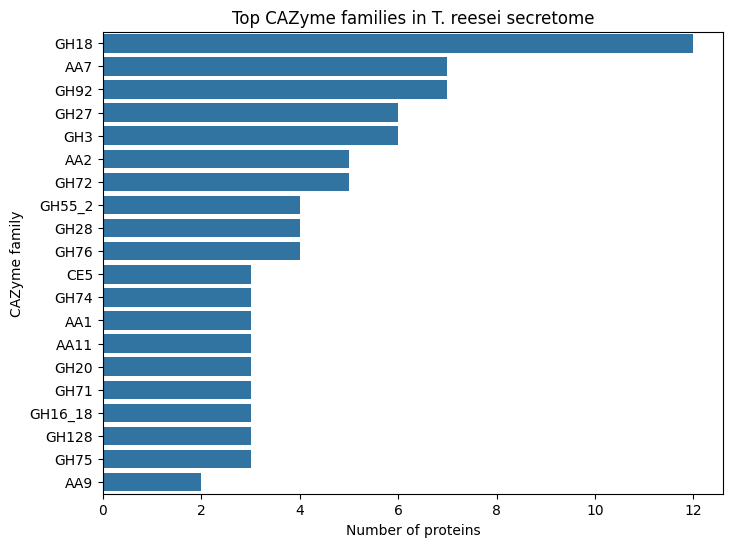

In [88]:
top20 = family_counts.head(20)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top20["count"],
    y=top20["family"]
)

plt.xlabel("Number of proteins")
plt.ylabel("CAZyme family")
plt.title("Top CAZyme families in T. reesei secretome")
plt.savefig("N:\Jupiter_Projects\enzyme-genome-mining-course/results/figures/cazyme_families.png")
plt.show()

In [91]:
arch_plot = hits_merged.copy()

arch_plot["domain"] = arch_plot["family"]
arch_plot["protein"] = arch_plot["query"]

arch_plot = arch_plot.merge(
    df3[["protein_id","length"]],
    left_on="protein",
    right_on="protein_id"
)

multi = arch_plot.groupby("protein").filter(lambda x: len(x) > 1)

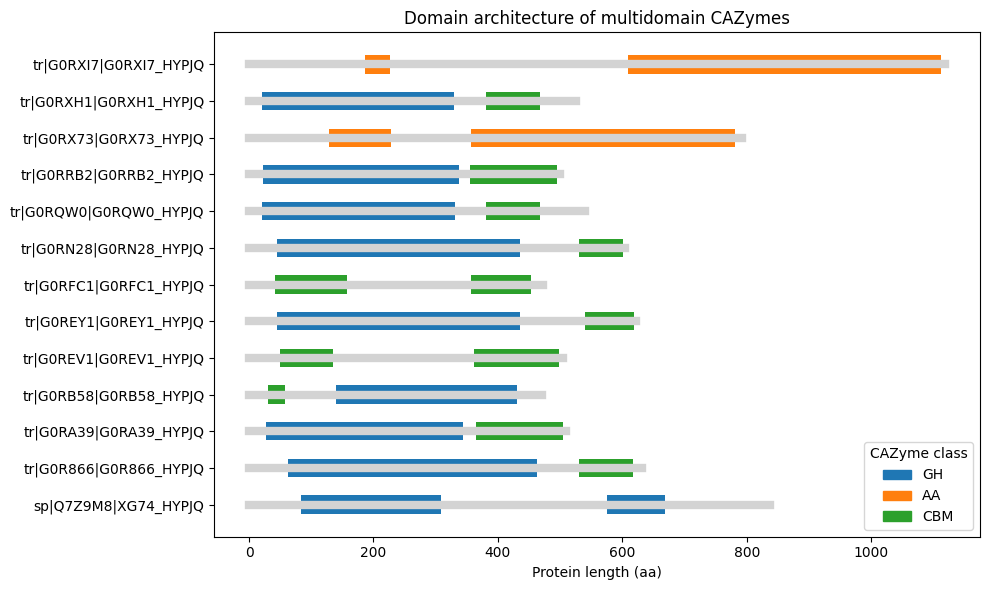

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

# extract class from family
arch_plot["class"] = arch_plot["domain"].str.extract("(GH|AA|CBM|CE|PL|GT)")

# class color palette
class_colors = {
    "GH": "#1f77b4",
    "AA": "#ff7f0e",
    "CBM": "#2ca02c"}

plt.figure(figsize=(10,6))

proteins = multi["protein"].unique()

for i, protein in enumerate(proteins):

    p = multi[multi["protein"] == protein]

    length = p["length"].iloc[0]

    # backbone
    plt.plot([0, length], [i, i], color="lightgray", linewidth=6)

    for _, row in p.iterrows():

        start = row["ali_from"]
        end = row["ali_to"]
        domain_class = row["class"]

        color = class_colors.get(domain_class, "gray")

        plt.barh(
            i,
            end - start,
            left=start,
            height=0.5,
            color=color
        )

plt.yticks(range(len(proteins)), proteins)

plt.xlabel("Protein length (aa)")
plt.title("Domain architecture of multidomain CAZymes")

# legend
handles = [
    plt.Rectangle((0,0),1,1,color=c)
    for c in class_colors.values()
]

plt.legend(handles, class_colors.keys(), title="CAZyme class")

plt.tight_layout()

plt.savefig("../results/figures/domain_architecture.png")

plt.show()

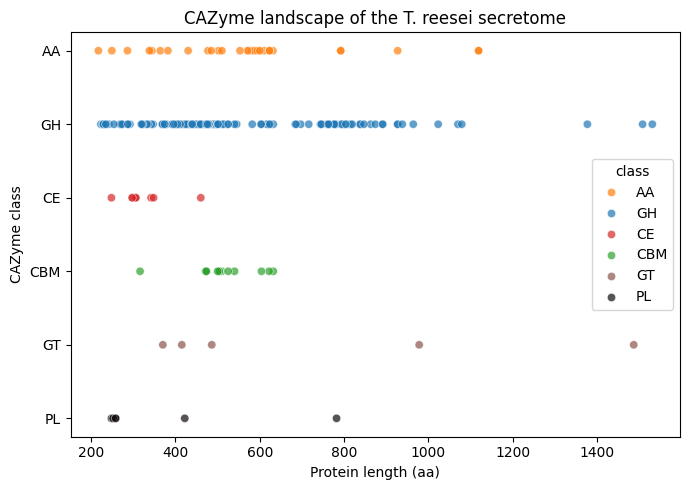

In [102]:
plot_df = hits_merged.merge(
    df3[["protein_id","length"]],
    left_on="query",
    right_on="protein_id"
)

# class color palette
class_colors = {
    "GH": "#1f77b4",
    "AA": "#ff7f0e",
    "CBM": "#2ca02c",
    "CE": "#d62728",
    "PL": "#120c0c",
    "GT": "#8c564b"
}


plot_df["class"] = plot_df["family"].str.extract("(GH|AA|CBM|CE|PL|GT)")

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=plot_df,
    x="length",
    y="class",
    hue="class",
    palette=class_colors,
    alpha=0.7
)

plt.xlabel("Protein length (aa)")
plt.ylabel("CAZyme class")
plt.title("CAZyme landscape of the T. reesei secretome")

plt.tight_layout()

plt.savefig("../results/figures/cazyme_landscape.png")

plt.show()